![Title Image](your_image.png)

<span style="color:black; font-weight:bold; font-size:24px;">Objective:</span>

<span style="color:black; font-weight:bold; font-size:20px;"> Heart Disease Prediction</span><br>
<span style="color:black; font-weight:regular; font-size:20px;"> Build a model to predict whether a person is at risk of heart disease based on their health data.</span>

<span style="color:black; font-weight:bold; font-size:20px;">Export all required libraries</span>

In [155]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sb

from sklearn.model_selection import train_test_split

from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, r2_score, f1_score, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score

In [156]:
#Data loaded using the pandas library
df=pd.read_csv('heart_disease.csv')
df.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


<span style="color:black; font-weight:bold; font-size:20px;">Exploratory Data Analysis (EDA)</span>

<span style="color:black; font-weight:bold; font-size:18px;">Missing Values</span>

In [157]:
#No of rows & columns in the data
df.shape

(303, 14)

In [158]:
#No of elements/observations/datapoints in the data
df.size

4242

In [159]:
#summary of the data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [160]:
#Statictical summary of the data
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


In [161]:
#check the missing values in the data
df.isnull().mean()*100

age         0.000000
sex         0.000000
cp          0.000000
trestbps    0.000000
chol        0.000000
fbs         0.000000
restecg     0.000000
thalach     0.000000
exang       0.000000
oldpeak     0.000000
slope       0.000000
ca          1.320132
thal        0.660066
target      0.000000
dtype: float64

In [162]:
#displayed the rows which has missing values
df[df['ca'].isnull()]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
166,52.0,1.0,3.0,138.0,223.0,0.0,0.0,169.0,0.0,0.0,1.0,NaN,3.0,0
192,43.0,1.0,4.0,132.0,247.0,1.0,2.0,143.0,1.0,0.1,2.0,NaN,7.0,1
287,58.0,1.0,2.0,125.0,220.0,0.0,0.0,144.0,0.0,0.4,2.0,NaN,7.0,0
302,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,NaN,3.0,0


In [163]:
df[df['thal'].isnull()]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
87,53.0,0.0,3.0,128.0,216.0,0.0,2.0,115.0,0.0,0.0,1.0,0.0,NaN,0
266,52.0,1.0,4.0,128.0,204.0,1.0,0.0,156.0,1.0,1.0,2.0,0.0,NaN,1


In [164]:
print('Ca missing values:', df['ca'].isna().sum())
print('thal missing values:', df['thal'].isna().sum())

Ca missing values: 4
thal missing values: 2


<span style="color:black; font-weight:bold; font-size:14px;">Explanation:</span><br>
<span style="color:black; font-size:14px;">
The dataset (heart_disease) was loaded and missing values were checked. It was found that two columns contain missing values, and the corresponding rows were displayed.
</span>

<span style="color:black; font-weight:bold; font-size:18px;">Check the trend and relationship between inputs</span><br>

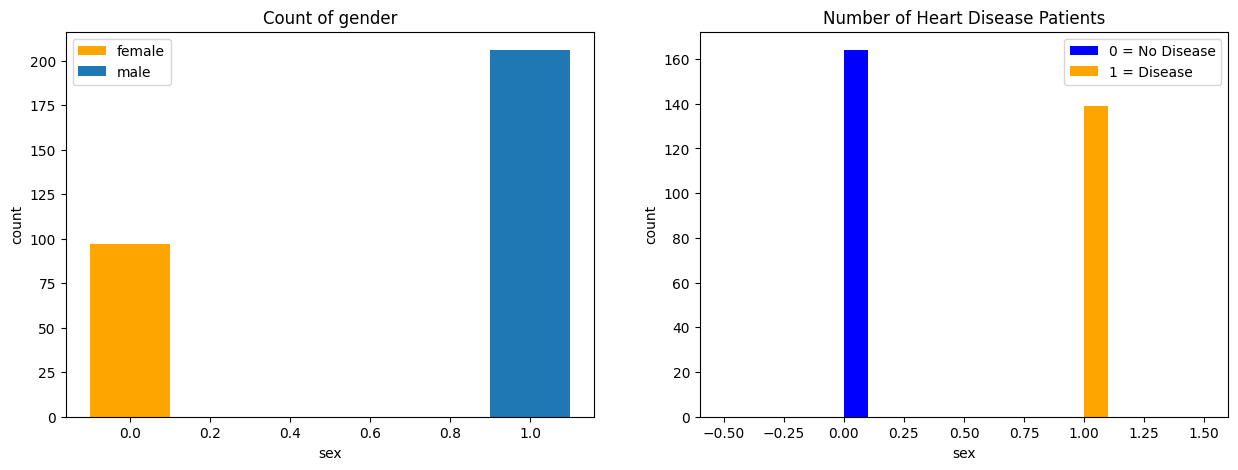

In [165]:
#Check the trend and analysis between inputs
plt.figure(figsize=(15,5))
#--------------------Count of gender(male,female)----------------------
plt.subplot(1,2,1)
plt.hist(df[df['sex']==0]['sex'], bins=[-0.5, 0.5, 1.5],color='orange',rwidth=0.2, label='female')
plt.hist(df[df['sex']==1]['sex'], bins=[-0.5, 0.5, 1.5], rwidth=0.2, label='male')
plt.xlabel('sex')
plt.ylabel('count')
plt.title('Count of gender')
plt.legend()

#--------------------Number of disease patients gender(male,female)----------------------
plt.subplot(1,2,2)
plt.hist(df[df['target']==0]['target'], color='blue', label='0 = No Disease')
plt.hist(df[df['target']==1]['target'], color='orange', label='1 = Disease')
plt.xlabel('sex')
plt.ylabel('count')
plt.title('Number of Heart Disease Patients')
plt.legend()



<span style="color:black; font-weight:bold; font-size:18px;">Analyze relationship between inputs & Output</span><br>

Text(0.5, 1.0, 'Number of Heart Disease Patient w.r.t Age')

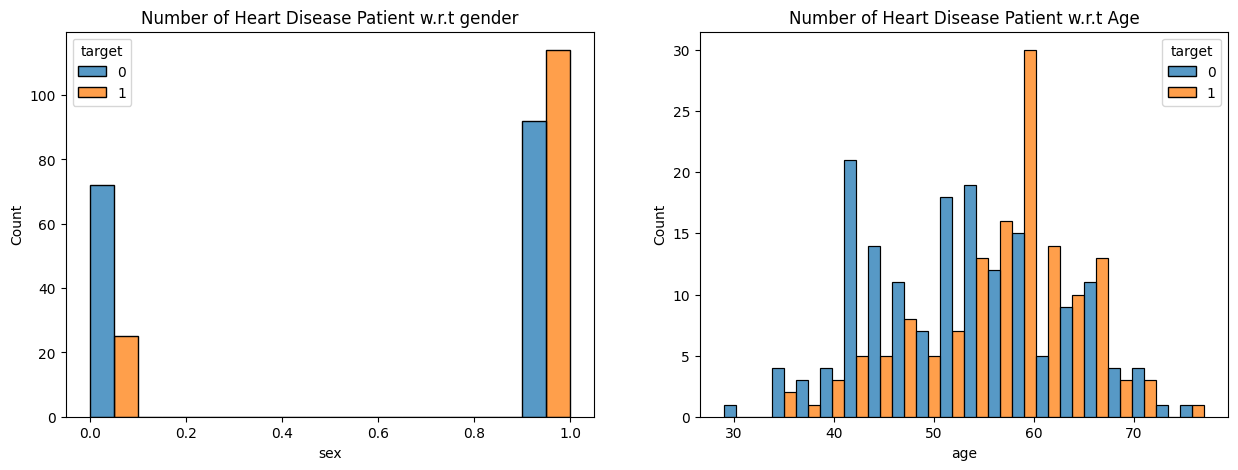

In [166]:
plt.figure(figsize=(15,5))
#--------------------Number of heart Disease w.r.t(male,female)----------------------
plt.subplot(1,2,1)
sb.histplot(x=df['sex'], hue=df['target'], multiple='dodge')
plt.title('Number of Heart Disease Patient w.r.t gender')


plt.subplot(1,2,2)          
sb.histplot(x=df['age'], hue=df['target'], bins=20, multiple='dodge')
plt.title('Number of Heart Disease Patient w.r.t Age')

<span style="color:black; font-weight:bold; font-size:14px;">Explanation:</span><br>
<span style="color:black; font-size:14px;">
Two graphs were displayed to understand the trend of inputs.
1st graph: First plot shows the number of sex(male,female) are present in the data and Second plot shows the number of heart disease patients according to sex(male,female). We can see clearly number of males is high in the data and Male heart disese patients are also higher than female.
</span><br>
<span style="color:black; font-size:14px;">
Two graphs were displayed to understand the trend of inputs.
1st graph: First plot shows the distribution of heart disease and no disease according to the number of sex(male,female) and Second plot shows the number of heart disease patients according to age. 
</span><br>
<span style="color:black; font-size:14px;">
We can see clearly number of heart disease males between the age(55-65) are getting effective than those people whose age is less that 55 and more than 70, also females heart disease patients are less than the male patients.

<span style="color:black; font-weight:bold; font-size:22px;">Data Preprocessing</span>

<span style="color:black; font-weight:bold; font-size:18px;">Fill the Missing Values with the mean</span>

In [167]:
df1=df.copy() #---------------copy of the data

In [168]:
df1[df1['ca'].isnull()]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
166,52.0,1.0,3.0,138.0,223.0,0.0,0.0,169.0,0.0,0.0,1.0,NaN,3.0,0
192,43.0,1.0,4.0,132.0,247.0,1.0,2.0,143.0,1.0,0.1,2.0,NaN,7.0,1
287,58.0,1.0,2.0,125.0,220.0,0.0,0.0,144.0,0.0,0.4,2.0,NaN,7.0,0
302,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,NaN,3.0,0


In [169]:
df1['ca'].isnull().sum()#---------------number of missing values

np.int64(4)

In [170]:
#---------------To fill the missing values calculate the mean of the columns which has missing values
mean_ca=df1['ca'].mean()
mean_thal=df1['thal'].mean()
print('mean_ca:',mean_ca)
print('mean_thal:',mean_thal)

mean_ca: 0.6722408026755853
mean_thal: 4.73421926910299


In [171]:
df1['ca']=df1['ca'].fillna(mean_ca)
df1['thal']=df1['thal'].fillna(mean_thal)

In [172]:
df1.sample(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
46,51.0,1.0,3.0,110.0,175.0,0.0,0.0,123.0,0.0,0.6,1.0,0.0,3.0,0
55,54.0,1.0,4.0,124.0,266.0,0.0,2.0,109.0,1.0,2.2,2.0,1.0,7.0,1
237,46.0,1.0,4.0,120.0,249.0,0.0,2.0,144.0,0.0,0.8,1.0,0.0,7.0,1
111,56.0,1.0,4.0,125.0,249.0,1.0,2.0,144.0,1.0,1.2,2.0,1.0,3.0,1
44,61.0,0.0,4.0,130.0,330.0,0.0,2.0,169.0,0.0,0.0,1.0,0.0,3.0,1


In [173]:
df1.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [174]:
#---------------print the mean values
print('Ca missing values:', df1['ca'].isna().sum())
print('thal missing values:', df1['thal'].isna().sum())

Ca missing values: 0
thal missing values: 0


<span style="color:black; font-weight:bold; font-size:20px;">Analyze the Data after filling the missing values</span>

<span style="color:black; font-weight:bold; font-size:18px;">Distribution of ca & thal</span>

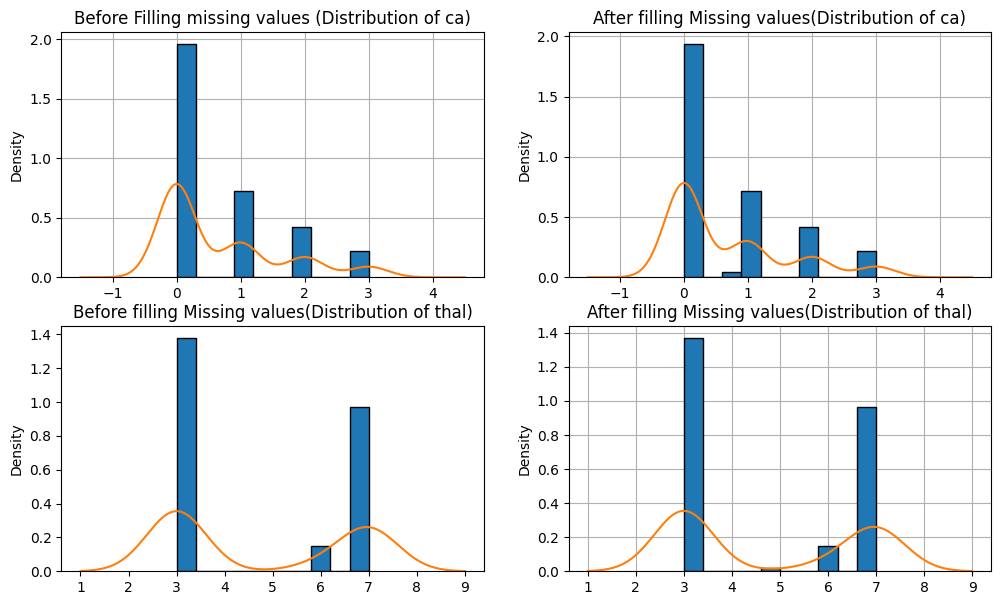

In [175]:
plt.figure(figsize=(12,7))

#------------------------Distribution of ca--------------------
plt.subplot(2,2,1)
df['ca'].plot(kind='hist', density=True, edgecolor='black')
df['ca'].plot(kind='kde')
plt.title('Before Filling missing values (Distribution of ca)')
plt.grid(True)
plt.gca().set_axisbelow(True)

plt.subplot(2,2,2)
df1['ca'].plot(kind='hist', density=True, edgecolor='black')
df1['ca'].plot(kind='kde')

plt.title('After filling Missing values(Distribution of ca)')

plt.grid(True)
plt.gca().set_axisbelow(True)

#------------------------Distribution of thal--------------------
plt.subplot(2,2,3)
df['thal'].plot(kind='hist', density=True, edgecolor='black')
df['thal'].plot(kind='kde')
plt.title('Before filling Missing values(Distribution of thal)')

plt.subplot(2,2,4)
df1['thal'].plot(kind='hist', density=True, edgecolor='black')
df1['thal'].plot(kind='kde')

plt.title('After filling Missing values(Distribution of thal)')

plt.grid(True)
plt.gca().set_axisbelow(True)


<span style="color:black; font-weight:bold; font-size:18px;">Outliers</span>

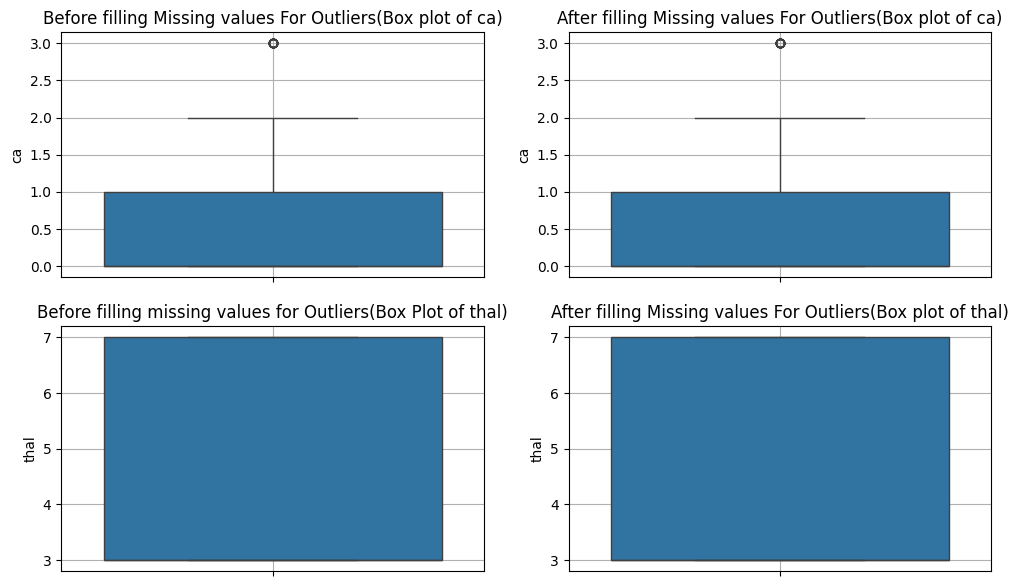

In [176]:
plt.figure(figsize=(12,7))
#------------------------Outlier for ca--------------------
plt.subplot(2,2,1)
sb.boxplot(df['ca'])
plt.title('Before filling Missing values For Outliers(Box plot of ca)')
plt.grid(True)
plt.gca().set_axisbelow(True)

plt.subplot(2,2,2)
sb.boxplot(df1['ca'])
plt.title('After filling Missing values For Outliers(Box plot of ca)')
plt.grid(True)
plt.gca().set_axisbelow(True)

#------------------------Outlier for thal--------------------
plt.subplot(2,2,3)
sb.boxplot(df['thal'])
plt.title('Before filling missing values for Outliers(Box Plot of thal)')
plt.grid(True)
plt.gca().set_axisbelow(True)

plt.subplot(2,2,4)
sb.boxplot(df1['thal'])
plt.title('After filling Missing values For Outliers(Box plot of thal)')
plt.grid(True)
plt.gca().set_axisbelow(True)

<span style="color:black; font-weight:bold; font-size:14px;">Explanation:</span><br>
<span style="color:black; font-size:14px;">
Calculated the mean values using the pandas library.Then filled the missing values in ca & thal with the mean of ca & thal column.
</span><br>
<span style="color:black; font-size:14px;">
Two graphs were displayed to see the behaviour of input columns which has missing values.
1st graph: It clearly shows the distribution of ca & thal before and after filling the missing values.We can see distribution is same after filling the missing values with the mean.
</span><br>
<span style="color:black; font-size:14px;">
2nd graph: It shows the outliers in the data of ca & thal. There is no change in the outliers before and after filling the missing values.
</span><br>
<span style="color:black; font-size:14px;">
We can clearly see distribution of the data is same before and after filling the missing vlaues So data remain same if we fill missing values with the mean of data
</span><br>


<span style="color:black; font-weight:bold; font-size:18px;">Relationship between input & output</span>

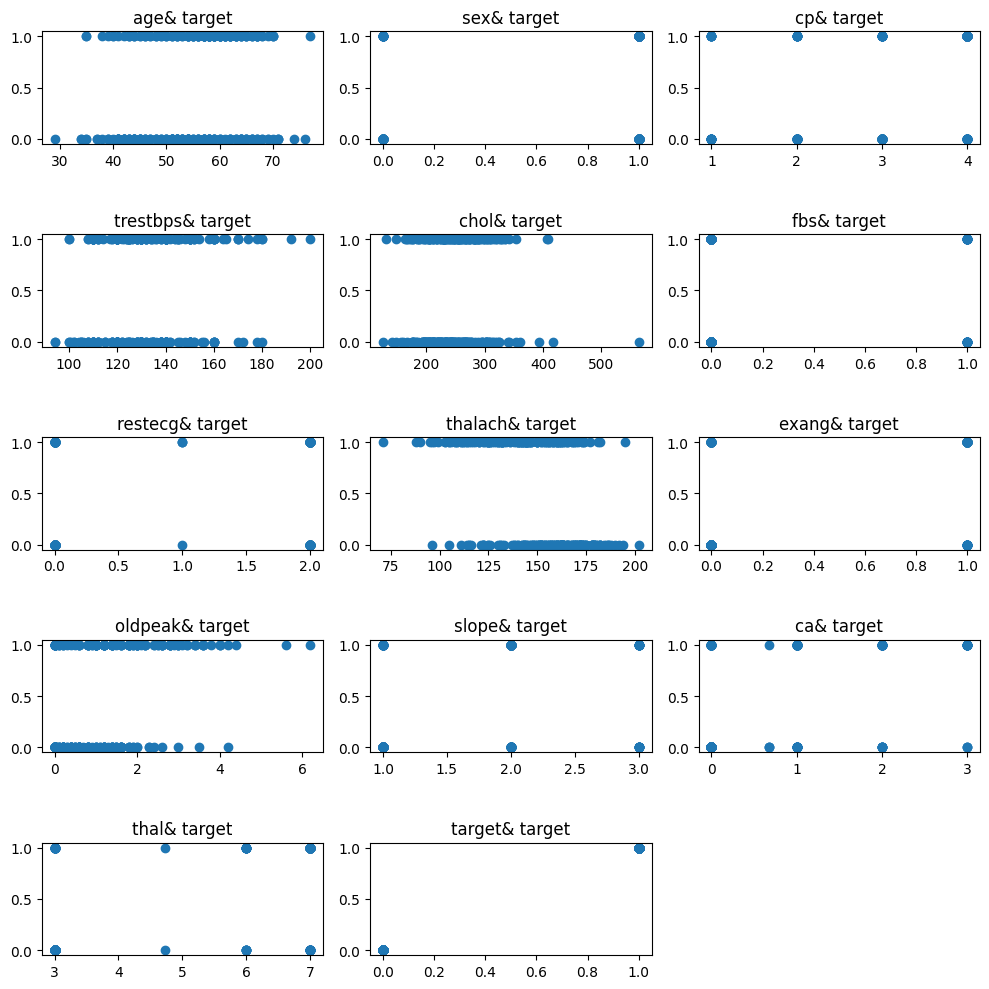

In [177]:
plt.figure(figsize=(10,10))
index=0
for i in df1.columns:
    index+=1
    plt.subplot(5,3,index)
    plt.scatter(df1[i], df1['target'])
    plt.title(str(i)+'& target')
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.8)

In [178]:
X=df1.drop(columns=['target'])
Y=df1['target']

In [179]:
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X)

Text(0.5, 1.0, 'Distribution of Data (Non-Linear)')

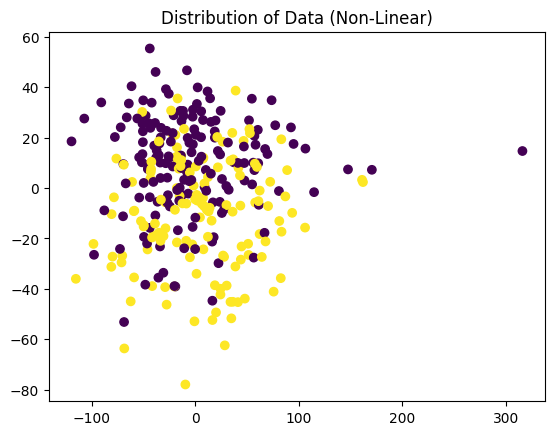

In [180]:
plt.scatter(X_pca[:,0],X_pca[:,1], c=Y)
plt.title('Distribution of Data (Non-Linear)')

<span style="color:black; font-weight:bold; font-size:14px;">Explanation:</span><br>
<span style="color:black; font-size:14px;">
Graphs were plotted between input and output to analyse the relationship between input and output. We can clearly see relationshipe bw i/o is non-linear.
</span><br>

<span style="color:black; font-weight:bold; font-size:22px;">Train the model</span><br>

In [181]:
df1.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [182]:
df1.shape

(303, 14)

In [183]:
XX=df1.drop(columns=['target'])
YY=df1['target']

In [184]:
x_train,x_test,y_train,y_test=train_test_split(XX,YY,random_state=41, test_size=0.2)

In [185]:
lr=LogisticRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning:

lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



<span style="color:black; font-weight:bold; font-size:22px;">Evaluate the model</span><br>

<span style="color:black; font-weight:bold; font-size:18px;">Accuracy and Confusion Matrix of the Model</span><br>

In [186]:
print('Accuracy:',str(np.round(accuracy_score(y_test,y_pred)*100,1))+'%')
print('Confusion_Matrix:\n', confusion_matrix(y_test,y_pred))

Accuracy: 88.5%
Confusion_Matrix:
 [[37  3]
 [ 4 17]]


<span style="color:black; font-weight:bold; font-size:18px;">Final Classification line of the Model</span><br>

<Axes: >

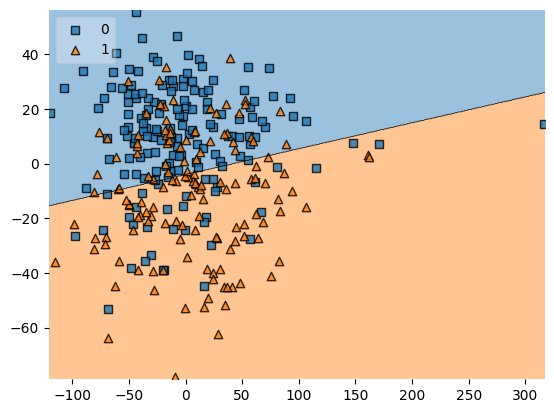

In [187]:
y_n=Y.to_numpy()

lrg=LogisticRegression()
lrg.fit(X_pca,y_n)

from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_pca,y_n, lrg,legend=2)

<span style="color:black; font-weight:bold; font-size:18px;">ROC curve of the Model</span><br>

In [188]:
#Get the probabilities of output
y_prob=lr.predict_proba(x_test)[:,1]

In [189]:
#Get the TruePositiveRate & FalsePositiveRate & threshold values
fpr,tpr,threshold=roc_curve(y_test,y_prob)

In [190]:
auc=roc_auc_score(y_test,y_prob)
auc

0.8976190476190476

In [191]:
[thr for thr in threshold[indices]]

[np.float64(inf),
 np.float64(0.95887464062462),
 np.float64(0.8423352064139408),
 np.float64(0.7038786930417551),
 np.float64(0.6053553774229462),
 np.float64(0.41592411590775497),
 np.float64(0.20876769906876566),
 np.float64(0.13581936132226144),
 np.float64(0.1190434491953373)]

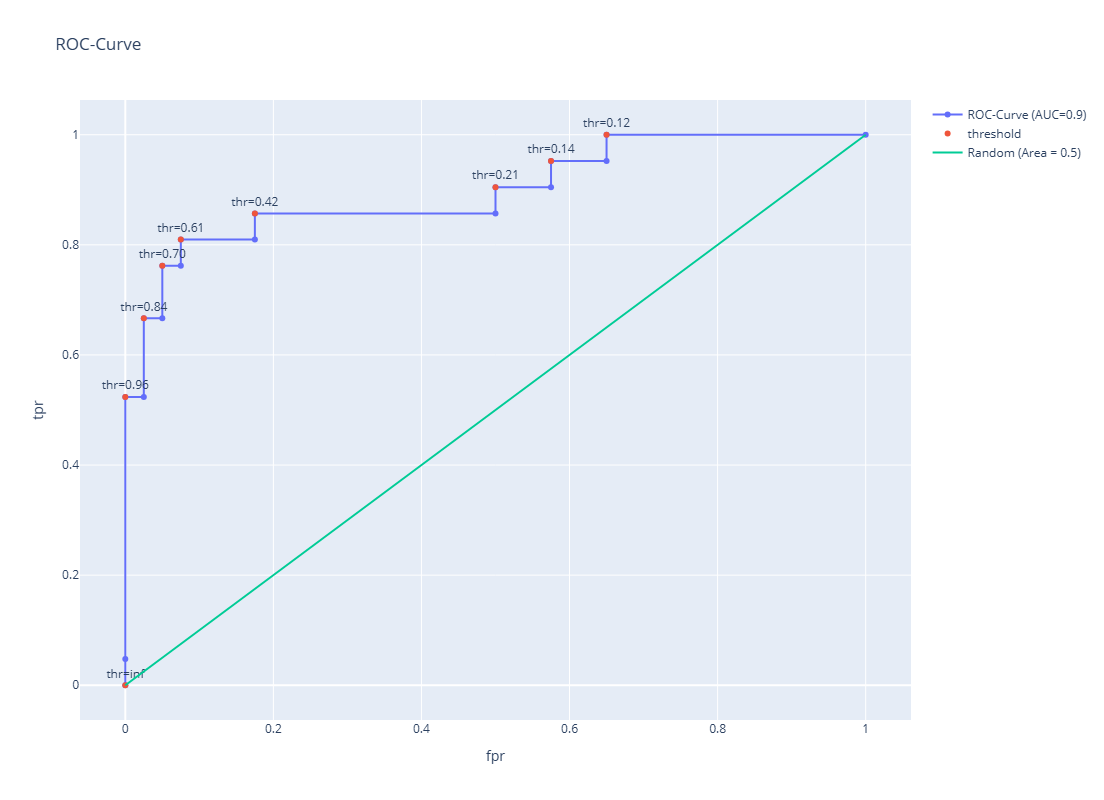

In [192]:
#ROC curve
trace0=go.Scatter(x=fpr, y=tpr,name='ROC-Curve (AUC={})'.format(np.round(auc,2)))

#labels on ROC curve
n=2
indices=np.arange(len(threshold))%n==0
trace1=go.Scatter(x=fpr[indices], y=tpr[indices], mode='markers+text', name='threshold', text=[f"thr={thr:.2f}" for thr in threshold[indices]], textposition='top center')

#Straigh line
trace2=go.Scatter(x=[0, 1], y=[0,1], mode='lines',name='Random (Area = 0.5)')


layout=go.Layout(title='ROC-Curve', xaxis=dict(title='fpr'), yaxis=dict(title='tpr'), width=1000, height=800)

data=[trace0, trace1, trace2]

go.Figure(data=data, layout=layout)

<span style="color:black; font-weight:bold; font-size:14px;">Explanation:</span><br>
<span style="color:black; font-size:14px;">
Trained the model using logistic regression algorithm. Calculated the accuracy, confusion matrix of the model, which tells the model performance.
The accuracy score and confusion is showing that model is making fewer mistakes(less wrong predictions), In confusion matrix True Positive & True Negative values are higher than False negative & False positive which mean model is classifying well.
Plotted the ROC(Receiver Operating Characteristics) which shows the output results(True positive rate, False positive rate) on the basis of threshold values.
</span><br>
<span style="color:black; font-weight:bold; font-size:14px;">Conclusion:</span><br>
We can clearly see if threshold is 0.9 TPR is 0.5, FPR is 0 meaning we are missing 50% truepositive values  & if Threshold is 0.12 TPR is 1, FPR is 0.65 mean we are getting many wrong predictions.
SO best threshold will be between TPR and FPR is 0.21 where TPR is 0.9 and FPR is 0.5 means we will get 90% true positive values and 50% false positive values.
</span><br>

<span style="color:black; font-weight:bold; font-size:22px;">Highlight important features affecting prediction.</span><br>

In [211]:
pd.DataFrame(lr.coef_,columns=XX.columns, index=['weights'])

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
weights,-0.044481,0.807697,0.324396,0.023278,0.000695,-0.190192,0.312048,-0.036263,0.505316,0.493471,0.061121,1.149369,0.314455


<span style="color:black; font-weight:bold; font-size:14px;">Explanation:</span><br>
<span style="color:black; font-size:14px;">
Calculated the weights(coefficients) of all the inputs. As we know coefficeint indicates the importance of the input inthe output. If coefficient is high of the input it means that input has high contribution in the output.In our case, we can say Input feature 'ca' is important than all the other features because its coefficeint(1.14) is higher than others and this feature(ca) pushes prediction towards output 1. </span><br>
The feature 'fbs' has small value of coefficient it mean this feature has lower contribution in the output of 1 but it pushes prediction towards 0. 
</span><br>